In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

import json
import joblib


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)


In [3]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])
df.head()


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation
0,2014-12-31 23:00:00,9484.0,0.5,96.0,-0.1,92.66,734.81
1,2015-01-01 00:00:00,9484.0,0.1,95.0,-0.5,92.66,734.81
2,2015-01-01 01:00:00,9152.0,-0.2,95.0,-0.9,92.66,734.81
3,2015-01-01 02:00:00,8799.0,-0.4,95.0,-1.2,92.66,766.64
4,2015-01-01 03:00:00,8567.0,-0.6,95.0,-1.3,92.66,733.13


In [4]:
target = "load_actual"

X = df[feature_names]
y = df[target]


In [5]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))


In [6]:
def create_sequences(X, y, lookback=24):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

lookback = 24
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)


In [7]:
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test  = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test  = y_seq[train_size:]


In [8]:
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(lookback, X_train.shape[2])),
    MaxPooling1D(pool_size=2),

    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,361 (44.38 KB)

 Trainable params: 11,361 (44.38 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, 
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0181 - val_loss: 0.0131
Epoch 2/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0140 - val_loss: 0.0125
Epoch 3/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0134 - val_loss: 0.0124
Epoch 4/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0131 - val_loss: 0.0126
Epoch 5/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0129 - val_loss: 0.0122
Epoch 6/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0127 - val_loss: 0.0118
Epoch 7/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0126 - val_loss: 0.0120
Epoch 8/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0124 - val_loss: 0.0116
Epoch 9/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0123 - val_loss: 0.0119
Epoch 10/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0122 - val_loss: 0.0118
Epoch 11/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0121 - val_loss: 0.0115
Epoch 12/20
1972/1972 ━━━━━━━━

In [10]:
pred_scaled = model.predict(X_test)
pred = scaler_y.inverse_transform(pred_scaled)

y_test_actual = scaler_y.inverse_transform(y_test)

548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [11]:
mae_cnn = mean_absolute_error(y_test_actual, pred)
rmse_cnn = mean_squared_error(y_test_actual, pred) ** 0.5
mape_cnn = np.mean(np.abs((y_test_actual - pred) / y_test_actual)) * 100

print("CNN Results:")
print("MAE:", mae_cnn)
print("RMSE:", rmse_cnn)
print("MAPE:", mape_cnn)

CNN Results:
MAE: 598.7244170022219
RMSE: 787.0969795235968
MAPE: 6.342318823626479


In [12]:
model.save("../saved_models/cnn_model.h5")
joblib.dump(scaler_X, "../saved_models/cnn_scaler_X.pkl")
joblib.dump(scaler_y, "../saved_models/cnn_scaler_y.pkl")


['../saved_models/cnn_scaler_y.pkl']

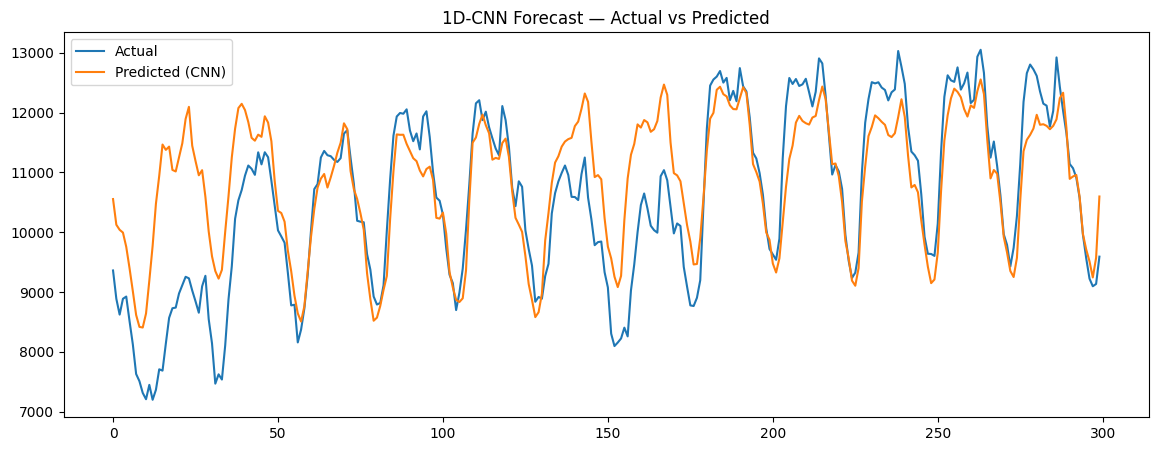

In [13]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(pred[:300], label="Predicted (CNN)")
plt.legend()
plt.title("1D-CNN Forecast — Actual vs Predicted")
plt.show()